In [1]:
import numpy as np
import pandas as pd
import random, os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import RandomOverSampler
import joblib

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Employee-Attrition - Employee-Attrition.csv")

In [4]:
df.drop(['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], axis=1,inplace=True)

In [5]:
le_attrition = LabelEncoder()
le_gender = LabelEncoder()
le_overtime = LabelEncoder()

df['Attrition'] = le_attrition.fit_transform(df['Attrition'])
df['Gender'] = le_gender.fit_transform(df['Gender'])
df['OverTime'] = le_overtime.fit_transform(df['OverTime'])

# One-hot encode
one_hot_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)




In [6]:
selected_features =['Age', 'DailyRate','DistanceFromHome','JobLevel','JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'OverTime','StockOptionLevel','PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany',
       'YearsInCurrentRole','YearsWithCurrManager','MaritalStatus_Single']


In [7]:
x = df[selected_features].copy()
y = df["Attrition"]   # Already label encoded earlier


In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [9]:
one_hot_cols = ['MaritalStatus_Single','OverTime']
ordinal_cols = ['JobLevel', 'JobSatisfaction','StockOptionLevel']

# Identify continuous numeric columns to scale
continuous_cols = [col for col in x_train.columns
                   if col not in one_hot_cols + ordinal_cols]

print("Continuous columns to scale:", continuous_cols)

# Scale only continuous features
scaler = StandardScaler()
x_train[continuous_cols] = scaler.fit_transform(x_train[continuous_cols])
x_test[continuous_cols] = scaler.transform(x_test[continuous_cols])

Continuous columns to scale: ['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']


In [17]:
ros=RandomOverSampler(random_state=42)
x_train_over,y_train_over = RandomOverSampler().fit_resample(x_train,y_train)

In [18]:
pd.Series(y_train_over).value_counts()

Attrition
0    986
1    986
Name: count, dtype: int64

In [19]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=7,
    class_weight='balanced_subsample',
    random_state=42
)
rf.fit(x_train_over, y_train_over)


RandomForestClassifier(class_weight='balanced_subsample', max_depth=7,
                       n_estimators=500, random_state=42)

In [20]:
y_pred = rf.predict(x_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Test Accuracy: 0.8129251700680272
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       247
           1       0.42      0.45      0.43        47

    accuracy                           0.81       294
   macro avg       0.66      0.66      0.66       294
weighted avg       0.82      0.81      0.82       294

[[218  29]
 [ 26  21]]


In [21]:
y_pred_proba = rf.predict_proba(x_test)[:,1]

y_pred = (y_pred_proba >= 0.4).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.78      0.85       247
           1       0.38      0.72      0.50        47

    accuracy                           0.77       294
   macro avg       0.66      0.75      0.67       294
weighted avg       0.85      0.77      0.79       294

[[192  55]
 [ 13  34]]


In [22]:
from sklearn.metrics import roc_curve , roc_auc_score
y_prob = rf.predict_proba(x_test)

fpr,tpr,thresholds = roc_curve(y_test,y_prob[:,1])
auc_score = roc_auc_score(y_test,y_prob[:,1])

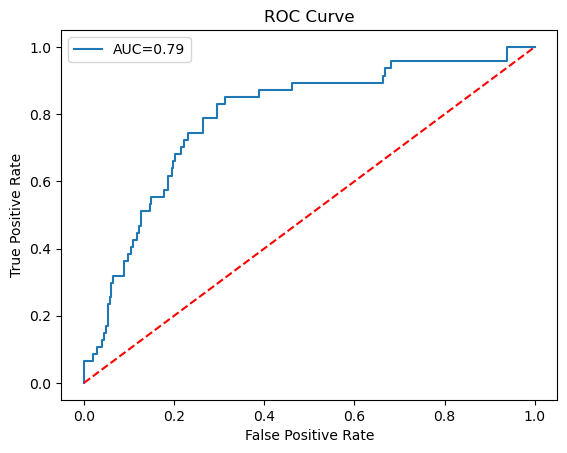

In [23]:
import matplotlib.pyplot as plt

plt.plot(fpr,tpr,label=f'AUC={auc_score:.2f}')
plt.plot([0,1],[0,1],linestyle='--',color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [24]:
# Save model
joblib.dump(rf, "final_rf_model.pkl")

#save encoder
joblib.dump(le_overtime, "le_overtime.pkl")


# Save scaler
joblib.dump(scaler, "final_scaler.pkl")

# Save oversampler (optional for retraining)
joblib.dump(ros, "final_oversampler.pkl")

# Save column names (VERY IMPORTANT)
joblib.dump(selected_features, "model_columns.pkl")




['model_columns.pkl']